In [82]:
%matplotlib inline
from pathlib import Path
import click
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.backends.backend_pdf
import matplotlib.style as mplstyle
import os
from datetime import datetime
import matplotlib.colors as mcolors

In [3]:
from hole_trajectory import calculate_trajectory_3d, plot_trajectory_3d, calc_binned_angles, plot_stability_comparison, calc_inclination, plot_inclination

In [4]:
mplstyle.use('fast')
plt.rcParams['lines.markersize'] = 1
plt.rcParams['font.size'] = 14
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['image.cmap'] = "viridis"
plt.rcParams['figure.max_open_warning'] = 50

In [5]:
from multi_log_reader import MultiLogReader
from preprocess import preprocess


In [44]:
#folder = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID Documents/Season Reports/2025/DataLog" 
folder = "/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2024/DataLog/" 
#print(os.listdir(path = folder))
start_date="20240625" #datetime.strptime(20240625,"%Y %m %d") 
end_date="20240626" #datetime.strptime(20240626,"%Y %m %d")
#out_file="paper_plots/%s_%s.pdf" % (start_date, end_date)

In [13]:
#@click.command
#@click.option("--folder", help="Folder containing BigRAID PLC logs", required=True)
#@click.option("--start", "start_date",
#              help="A start date in isoformat. Can optionally include a time as well.", required=True)
#@click.option("--end", "end_date",
#              default=None,
#              help="A end date. If not supplied, this defaults to end-of-day of the start date.")
#@click.option("--out", "out_file",
#              default=None,
#              help="Output path for the PDF. Defaults to a name based on the dates in the current folder")

In [45]:
#def plot(folder, start_date, end_date, out_file):
print(folder)
mr = MultiLogReader.find_files(folder, start_date, end_date)
df = mr.as_df()

if out_file is None:
    end_date_str = ""
    if end_date is not None:
        end_date_str = f"_{end_date}"
    out_file = Path(f"BigRAID_{start_date}{end_date_str}.pdf")
out_file = Path(out_file)
out_file = out_file.with_name(out_file.name.replace(":", "-"))
print(out_file)
#_plot(df, out_file)

/Users/delia/Library/CloudStorage/OneDrive-SharedLibraries-NERC/BAS BigRAID - Documents/Season Reports/2024/DataLog/
Error decoding record: err='unpack requires a buffer of 38 bytes', raw='b''', sep='b' ''
paper_plots/20240622_20240626.pdf


In [46]:
df = preprocess(df, run_depth_threshold=1.5)

Axes(0.481574,0.071806;0.307396x0.879651)


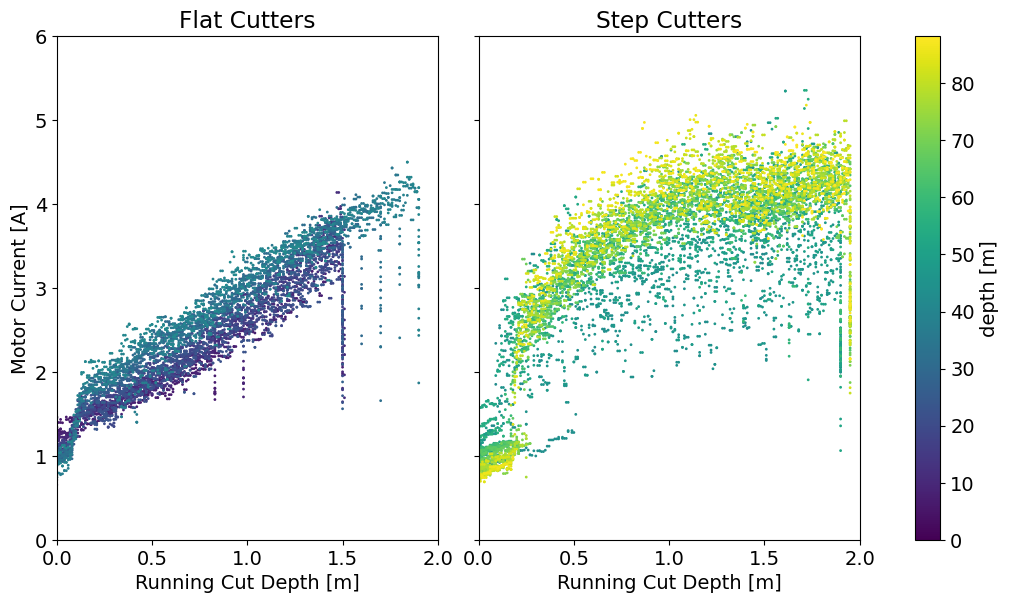

In [124]:
fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True)
fig.set_figwidth(10)
fig.set_figheight(6)

fig.suptitle('')
global_min = np.min(df["[PLC]WIRESPOOLEDOUT"])
global_max = np.max(df["[PLC]WIRESPOOLEDOUT"])
norm = mcolors.Normalize(vmin=global_min, vmax=global_max)

img0=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"] < 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = ax1, norm = norm, colorbar=False)
#plt.title("Motor Current vs Running Cut Depth")
ax1.set_xlabel("Running Cut Depth [m]")
ax1.set_ylabel("Motor Current [A]")
ax1.set_title("Flat Cutters")
ax1.set_ylim(0,6)
ax1.set_xlim(0,2)

img1=df[(df["cutting"] == 1) & (df["[PLC]WIRESPOOLEDOUT"] >= 42)].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="[PLC]WIRESPOOLEDOUT", s =1, rasterized=True, cmap="viridis", ax = ax2, norm = norm, colorbar=False)
print(o)
#plt.title("Motor Current vs Running Cut Depth")
ax2.set_xlabel("Running Cut Depth [m]")
ax2.set_ylabel("Motor Current [A]")
ax2.set_title("Step Cutters")
ax2.set_ylim(0,6)
ax2.set_xlim(0,2)


fig.colorbar(img0.collections[0],ax=[ax1,ax2], shrink=1, location='right', label= 'depth [m]')
plt.show()
fig.savefig("flat_vs_step_cutters_motor_current.pdf")


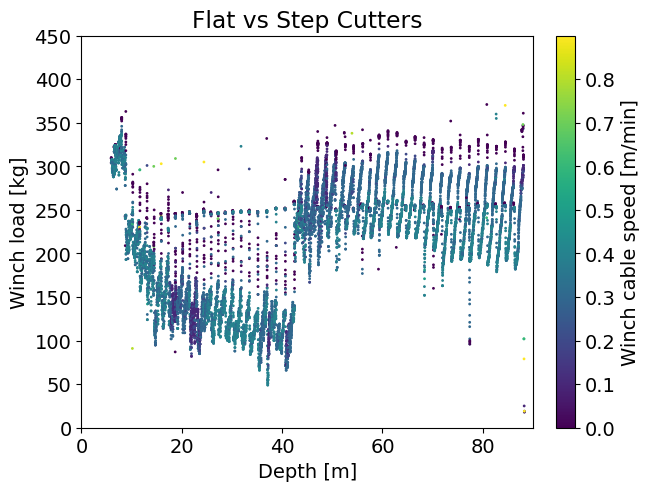

In [126]:
fig, ax = plt.subplots(1, 1)
#fig2.set_figwidth(5)
#fig2.set_figheight(6)
img=df[(df["cutting"] == 1)].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLETENSION", c="[PLC]CABLESPEED", s =1, rasterized=True, cmap="viridis", ax = ax, colorbar = False)#norm = norm)
ax.set_xlabel("Depth [m]")
ax.set_ylabel("Winch load [kg]")
ax.set_title("Flat vs Step Cutters")
ax.set_ylim(0,450)
ax.set_xlim(0,90)
fig.colorbar(img.collections[0],ax=ax, shrink=1, location='right', label= 'Winch cable speed [m/min]')
fig.savefig("flat_vs_step_cutters_winch_load.pdf")


In [69]:
# everything below here for reference
def _plot(df, out_path):
    # Add additional calculated columns to the data
    df = preprocess(df, run_depth_threshold=1.5)
    figures_start_idx = plt.gcf().number + 1

    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]DRILLACTIVECURRENT", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Motor Current vs Running Cut Depth")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylabel("Motor Current [A]")
    plt.ylim(0,6.5)
    plt.xlim(0,2.6)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLETENSION", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Depth [m]")
    plt.ylim(120,480)
    plt.xlabel("Depth [m]")
    plt.xlim(0,105)

    df[df["cutting"] == 1].plot.scatter(x="run", y="cut_depth",s =1, rasterized=True, cmap="viridis")
    #plt.title("Running Cut Depth per run")
    plt.ylabel("Running Cut Depth [m]")
    plt.xlabel("Run")
    plt.ylim(0,2.6)
    
    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="cut_depth",s =1, rasterized=True, cmap="viridis")
    #plt.title("Running Cut Depth per run")
    plt.ylabel("Running Cut Depth [m]")
    plt.xlabel("Depth [m]")
    plt.ylim(0,2.6)


    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]CABLETENSION", c="run", s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Running Cut Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylim(120,480)
    plt.xlim(0,2.6)

    df[df["cutting"] == 1].plot.scatter(x="cut_depth", y="[PLC]CABLETENSION", c="[PLC]CABLESPEED",s =1, rasterized=True, cmap="viridis")
    #plt.title("Cable Tension vs Running Cut Depth")
    plt.ylabel("Cable Tension [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.ylim(120,480)
    plt.xlim(0,2.6)

    df[(df["cutting"] == 1)].plot.scatter(x="cut_depth", y="weight_on_bit", c="run",s =1, rasterized=True, cmap="viridis")
    #plt.title("Estimated Weight on Bit vs Running Cut Depth")
    plt.ylabel("Weight On Bit [kg]")
    plt.xlabel("Running Cut Depth [m]")
    plt.xlim(0,2.6)
    plt.ylim(0,180)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]DRILLFEEDBACKVEL", c="[PLC]CABLESPEED",s =1, rasterized=True, cmap="viridis")
    #plt.title("RPM vs Running Cut Depth")
    plt.ylabel("Motor speed [RPM]")
    plt.xlabel("Depth [m]")
    plt.ylim(60,140)
    plt.xlim(0,100)

    df[df["cutting"] == 1].plot.scatter(x="[PLC]WIRESPOOLEDOUT", y="[PLC]CABLESPEED", c="[PLC]DRILLFEEDBACKVEL",s =1, rasterized=True, cmap="viridis")
    #plt.title("RPM vs Running Cut Depth")
    plt.ylabel("Rate of penetration [m/min]")
    plt.xlabel("Depth [m]")
    plt.ylim(0,1)
    plt.xlim(0,100)

    def group_duration(x):
        diff = x.diff()
        return diff[diff < np.timedelta64(10, 's')].sum()
    total = df[df["run"] > 0].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("total")
    cutting = df[df["cutting"] == 1].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("cutting")
    moving = df[df["[PLC]CABLESPEED"] > 2].index.to_series().groupby(df["run"]).agg(group_duration).dt.total_seconds().rename("moving")
    ejecting = df[df["[PLC]DRILLFEEDBACKVEL"] < -5].index.to_series().groupby(df["run"]).agg(np.ptp).dt.total_seconds().rename("ejecting")
    if "[PLC]ICECONVEYOR.SETSPEED" in df.columns:
        snowblower_travel = df[df['[PLC]ICECONVEYOR.SETSPEED'].abs() > 1].index.to_series().groupby(df["run"]).agg(group_duration).dt.total_seconds().rename("snowblower_travel")
    else:
        snowblower_travel = pd.Series(np.zeros(cutting.shape)).rename("snowblower_travel")
    grps = pd.concat([total, moving, cutting, ejecting, snowblower_travel], axis=1).fillna(0.0)
    
    fig = plt.figure()
    ax = plt.subplot()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    ax.bar(grps.index, grps['total'], color=colors[0], label="Total")
    ax.bar(grps.index, grps['cutting'], color=colors[1], label="Cutting")
    ax.bar(grps.index, grps['snowblower_travel'], color=colors[2], label="Snowblower Travel", bottom=grps['cutting'])
    ax.bar(grps.index, grps['ejecting'], color=colors[3], label="Ejecting", bottom=grps['cutting'] + grps['snowblower_travel'])
    ax.bar(grps.index, grps['moving'], color=colors[4], label="Moving", bottom=grps['cutting'] + grps['snowblower_travel'] + grps["ejecting"])
    ax.legend()
    #ax.set_title("Time per Run")
    ax.set_ylabel("Time [s]")
    ax.set_xlabel("Run")

    fig = plt.figure()
    ax = plt.subplot()
    run_cut_depth = df['cut_depth'].groupby(df['run']).max()
    run_cut_speed = (run_cut_depth / total) * 60 * 60
    run_auto_mode = df['[PLC]AUTOMODE'].groupby(df['run']).any()
    colors = ['tab:orange' if a else 'tab:blue' for a in run_auto_mode.values]
    labels = ['_A' if a else '_M' for a in run_auto_mode.values]
    if "_A" in labels:
        if (idx := labels.index("_A")) >= 0:
            labels[idx] = "Auto"
    if "_M" in labels:
        if (idx := labels.index("_M")) >= 0:
            labels[idx] = "Manual"
    ax.bar(run_cut_speed.index, run_cut_speed.values, color=colors, label=labels)

    # Plot the average
    ax.axhline(np.mean(run_cut_speed.values), 0, max(run_cut_speed.index))

    # Plot a regression line
    coeff = np.polyfit(run_cut_speed.index, run_cut_speed.values, 1)
    fit_fn = np.poly1d(coeff)
    ax.plot([0, max(run_cut_speed.index)], [fit_fn(0), fit_fn(max(run_cut_speed.index))], 'r--')

    fig.suptitle("Drilling Performance")
    ax.set_title("Cut length / Total time for the run")
    ax.set_ylabel("Drilling Performance [m/h]")
    ax.set_xlabel("Run")
    ax.legend(title="Mode")

    #fig, axes = plt.subplots(1, 3)
    display_max = 0
    for i, k in enumerate(["[PLC]IMUYAW","[PLC]IMUPITCH", "[PLC]IMUROLL"]):
        fig = plt.figure()
        ax = plt.subplot()
        d = df[(df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        #zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k]# - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        #print(i,k, vals.values)
        if k=="[PLC]IMUYAW":
            xmin = -180
            xmax = 180
        elif  k=="[PLC]IMUROLL":
            xmin = -2
            xmax = 2
        elif  k=="[PLC]IMUPITCH":
            xmin = -2
            xmax = 2
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], vals, bins=[int(depth_max/2), 50], range=[[0, depth_max], [xmin, xmax]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        ax.pcolormesh(yedges, xedges, H_norm_rows, rasterized=True, cmap="viridis")
        ax.set_title(k)
        ax.set_xlim(xmin, xmax)
        #ax.set_xlim(-display_max, display_max)
        #fig.title("Angle per Depth")
        ax.set_ylabel("Wire spooled out [m]")
        ax.set_xlabel("Angle [deg]")    
    yaw_rad = np.deg2rad(d["[PLC]IMUYAW"].values)
    pitch_rad= np.deg2rad(d["[PLC]IMUPITCH"].values)
    roll_rad = np.deg2rad(d["[PLC]IMUROLL"].values)

    fig, axes = plt.subplots(1, 2)
    display_max = 0
    for i, k in enumerate(["[PLC]IMUPITCH", "[PLC]IMUROLL"]):
        d = df[(df[k].abs() < 2) & (df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k] - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], d[k] - zero_offset, bins=[int(depth_max/2), 50], range=[[0, depth_max], [-2, 2]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        axes[i].pcolormesh(yedges, xedges, H_norm_rows, cmap="viridis")
        axes[i].set_title(k)
    for ax in axes:
        ax.set_xlim(-display_max, display_max)
    fig.suptitle("Angle per Depth")
    fig.supylabel("Wire spooled out [m]")
    fig.supxlabel("Angle [deg]")

    fig, axes = plt.subplots(1, 2)
    display_max = 0
    for i, k in enumerate(["hole_pitch", "hole_roll"]):
        d = df[(df[k].abs() < 2) & (df["[PLC]WIRESPOOLEDOUT"] > 2)]
        # subtract the mean when the drill is hanging freely above the hole
        zero_offset = df[(df["[PLC]WIRESPOOLEDOUT"] < 1) & (df["[PLC]CABLESPEED"].abs() < 0.1) & (df["[PLC]DRILLFEEDBACKVEL"].abs() < 0.1) & (df[k].abs() < 5.0)][k].mean()

        vals = d[k] - zero_offset
        display_max = max(vals.abs().quantile(0.99), display_max)
        depth_max = df['[PLC]WIRESPOOLEDOUT'].max()
        H, xedges, yedges = np.histogram2d(d["[PLC]WIRESPOOLEDOUT"], d[k] - zero_offset, bins=[int(depth_max/2), 50], range=[[0, depth_max], [-2, 2]])
        H_norm_rows = H / H.max(axis=1, keepdims=True)
        H_norm_rows = np.nan_to_num(H_norm_rows)
        axes[i].pcolormesh(yedges, xedges, H_norm_rows, cmap="viridis")

        # Plot a regression line
        coeff = np.polyfit(d["[PLC]WIRESPOOLEDOUT"].values, vals.values, 1)
        fit_fn = np.poly1d(coeff)
        axes[i].plot([fit_fn(0), fit_fn(depth_max)], [0, depth_max], 'r--')

        axes[i].set_title(k)
    for ax in axes:
        ax.set_xlim(-display_max, display_max)
    fig.suptitle("Angle per Depth, normalized using IMU Yaw")
    fig.supylabel("Wire spooled out [m]")
    fig.supxlabel("Angle [deg]")

    # Plot a 3D trajectory for the hole
    dz = 1.0
    mean_angles_x, std_dev_angles_x, angle_bin_sizes = calc_binned_angles(df, "hole_pitch", dz=dz)
    mean_angles_y, std_dev_angles_y, _= calc_binned_angles(df, "hole_roll", dz=dz)

    z_coords, x_mean, x_std, y_mean, y_std = calculate_trajectory_3d(
        mean_angles_x, std_dev_angles_x,
        mean_angles_y, std_dev_angles_y,
        dz=dz
    )
    plot_trajectory_3d(z_coords, x_mean, x_std, y_mean, y_std)

    # Do some stability checks on the trajectory.
    def _plot_stability(df_comp, subtitle):
        comp_mean_x, comp_std_x, _ = calc_binned_angles(df_comp, "hole_pitch", dz=dz)
        comp_mean_y, comp_std_y, _ = calc_binned_angles(df_comp, "hole_roll", dz=dz)

        comp_z_coords, comp_x_mean, comp_x_std, comp_y_mean, comp_y_std = calculate_trajectory_3d(
            comp_mean_x, comp_std_x,
            comp_mean_y, comp_std_y
        )

        plot_stability_comparison(z_coords, x_mean, x_std, y_mean, y_std, comp_z_coords, comp_x_mean, comp_y_mean, subtitle)

    ## Take only angles when the drill is moving up
    df_down = df[(df['[PLC]WIRESPOOLEDOUT'].diff() > 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_down, "Downgoing subset")

    ## When the drill is moving up
    df_up = df[(df['[PLC]WIRESPOOLEDOUT'].diff() < 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_up, "Upgoing subset")

    ## When the drill is drilling
    df_cutting = df[(df['cutting'] == 1) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_cutting, "Drill is cutting subset")

    ## When the drill is not drilling
    df_cutting = df[(df['cutting'] == 0) | (df["[PLC]CABLESPEED"].abs() < 0.1)].dropna()
    _plot_stability(df_cutting, "Drill is not cutting subset")

    incl_mean, incl_std = calc_inclination(mean_angles_x, std_dev_angles_x,
                                           mean_angles_y, std_dev_angles_y)
    plot_inclination(z_coords, incl_mean, incl_std / np.sqrt(angle_bin_sizes))

    df.plot.scatter(y="[PLC]WIRESPOOLEDOUT", x="[PLC]AUTODOWNSTOPDEPTH", c="run", cmap="viridis")
    plt.title("Stop Depth vs Depth")

    df_plt = df[df["[PLC]WIRESPOOLEDOUT"] == df["[PLC]WIRESPOOLEDOUT"].cummax()]

    df[["run", "cutting", "cut_depth", "[PLC]WIRESPOOLEDOUT"]].plot(use_index=False, rasterized=True)
    plt.figure()
    sampling_time = 1
    xtime_seconds =  sampling_time*np.arange(0,len(df["cut_depth"].values))
    xtime = xtime_seconds/60/60
    plt.scatter(xtime, df["[PLC]WIRESPOOLEDOUT"].values, s=1, rasterized=True)
    plt.xlabel("time from start [hrs]")
    plt.ylabel("depth [m]")  


    # plt.show()
    with matplotlib.backends.backend_pdf.PdfPages(out_path) as pdf:
        for fig in range(figures_start_idx,  plt.gcf().number + 1):
            pdf.savefig(fig)
            plt.close(fig)

In [ ]:
if __name__ == "__main__":
    plot()